# BERT Inference — A Hands-On Walkthrough

**ANLP Session 6 — Transformers & Language Models**

---

This notebook accompanies the paper *The Evolution of Text Embedding Models* and gives you hands-on experience with a real pre-trained BERT model. We will work through four demonstrations:

1. **Tokenisation** — how BERT breaks text into subword tokens
2. **Contextual embeddings** — the same word, two different meanings, two different vectors
3. **Masked Language Modelling** — asking BERT to fill in a blank
4. **Semantic similarity** — measuring how close two sentences are in BERT's embedding space

We use [`bert-base-uncased`](https://huggingface.co/google-bert/bert-base-uncased) from HuggingFace — a 110M parameter model pre-trained by Google on BooksCorpus and English Wikipedia.

## Setup

We need two libraries:
- `transformers` — HuggingFace library that provides pre-trained models and tokenisers
- `torch` — PyTorch, the deep learning framework BERT runs on

The first time you run the cell below, BERT's weights (~440 MB) will be downloaded and cached locally. Subsequent runs load from cache.

> **Note for Windows users:** HuggingFace's cache system prefers symlinks, which require Developer Mode on Windows. This does not affect functionality — files are cached correctly either way. The setup cell suppresses this advisory along with other informational messages so the output stays clean.

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import BertTokenizer, BertModel, BertForMaskedLM

# Download and load the tokeniser and model weights
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(MODEL_NAME)
mlm_model = BertForMaskedLM.from_pretrained(MODEL_NAME)

# Put both models in evaluation mode — we are doing inference, not training
model.eval()
mlm_model.eval()

print("Models loaded successfully.")
print(f"BERT parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded successfully.
BERT parameters: 109,482,240


---

## Part 1 — Tokenisation

BERT does not operate on whole words. It uses **WordPiece tokenisation**, a subword algorithm that breaks rare or unknown words into smaller pieces. This lets BERT handle any word, including ones it never saw during training.

BERT also adds two special tokens automatically:
- `[CLS]` — prepended to every sequence. By the final layer, its hidden state summarises the whole input. Used for classification tasks.
- `[SEP]` — marks the end of a sentence (or the boundary between two sentences).

Let's look at how BERT tokenises a couple of sentences.

In [24]:
sentences = [
    "The cat sat on the mat.",
    "Transformers revolutionised natural language processing.",
    "uncharacteristically",  # a long, rare word that gets split into many subwords
]

for sent in sentences:
    tokens = tokenizer.tokenize(sent)
    ids = tokenizer.encode(sent)  # includes [CLS] and [SEP]
    decoded = tokenizer.convert_ids_to_tokens(ids)

    print(f"Input    : {sent}")
    print(f"Tokens   : {tokens}")
    print(f"With special tokens: {decoded}")
    print(f"Token IDs: {ids}")
    print()

Input    : The cat sat on the mat.
Tokens   : ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']
With special tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
Token IDs: [101, 1996, 4937, 2938, 2006, 1996, 13523, 1012, 102]

Input    : Transformers revolutionised natural language processing.
Tokens   : ['transformers', 'revolution', '##ised', 'natural', 'language', 'processing', '.']
With special tokens: ['[CLS]', 'transformers', 'revolution', '##ised', 'natural', 'language', 'processing', '.', '[SEP]']
Token IDs: [101, 19081, 4329, 5084, 3019, 2653, 6364, 1012, 102]

Input    : uncharacteristically
Tokens   : ['un', '##cha', '##rac', '##ter', '##istic', '##ally']
With special tokens: ['[CLS]', 'un', '##cha', '##rac', '##ter', '##istic', '##ally', '[SEP]']
Token IDs: [101, 4895, 7507, 22648, 3334, 6553, 3973, 102]



**What to notice:**
- "revolutionised" is split into `['revolution', '##ised']` — BERT recognises the root but stores inflected forms as subword continuations.
- Subword pieces that continue a word are prefixed with `##` (e.g. `##ised`).
- "uncharacteristically" is split into many pieces (`['un', '##cha', '##rac', '##ter', '##istic', '##ally']`) — it is too rare to appear in the vocabulary whole, so WordPiece breaks it down into reusable fragments.
- Every sequence starts with `[CLS]` (token ID 101) and ends with `[SEP]` (token ID 102).

---

## Part 2 — Contextual Embeddings

The central claim of the paper is that BERT produces *different* vectors for the same word depending on context. Let's verify this directly with the classic example: the word **"bank"**.

- *"I sat on the river **bank** and watched the water."* → geographical meaning
- *"I deposited my savings at the **bank** this morning."* → financial meaning

We will extract BERT's hidden state for the token "bank" in each sentence and compare them using cosine similarity. If BERT is truly context-sensitive, the two vectors should be noticeably different.

In [32]:
def get_token_embedding(sentence, target_word, model, tokenizer):
    """
    Return the final-layer hidden state for a target word in a sentence.

    Handles WordPiece subword splits: if the target word is tokenised into
    multiple pieces (e.g. 'lender' → ['lend', '##er']), the embeddings of
    all pieces are averaged to produce a single word-level vector.
    """
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Find the span of subword tokens that reconstruct the target word.
    # We slide a window and join consecutive tokens (stripping '##') to check
    # whether they form the target word.
    target_indices = []
    for start in range(len(tokens)):
        reconstructed = tokens[start].lstrip("##")  # first piece has no ##

        # if token is a continuation piece (starts with '##'), skip it as a start candidate
        if reconstructed != tokens[start]:
            continue  # skip mid-word continuation pieces as start candidates
        span = [start]
        # Keep consuming '##' continuation pieces
        j = start + 1

        # check if next token is a continuation piece (starts with '##') and if so, add it to the span
        while j < len(tokens) and tokens[j].startswith("##"):
            reconstructed += tokens[j][2:] # strips '##'
            span.append(j)
            j += 1
        if reconstructed == target_word.lower():
            target_indices = span
            break

    if not target_indices:
        raise ValueError(
            f"Word '{target_word}' not found in tokens.\n"
            f"Tokens: {tokens}\n"
            f"Tip: BERT lowercases text (bert-base-uncased) and may split words into subwords."
        )

    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.last_hidden_state: (1, seq_len, 768)
    # Average over all subword pieces that make up the target word
    hidden_states = outputs.last_hidden_state[0]          # (seq_len, 768)
    word_embedding = hidden_states[target_indices].mean(dim=0).numpy()

    if len(target_indices) > 1:
        pieces = [tokens[i] for i in target_indices]
        print(f"  Note: '{target_word}' was split into {pieces} — averaged {len(pieces)} subword embeddings.")

    return word_embedding, tokens


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


sentence_river = "I sat on the tranquil river bank and watched the water."
sentence_money = "I noticed an overdraft fee when I checked my bank account this morning."

emb_river, tokens_river = get_token_embedding(sentence_river, "bank", model, tokenizer)
emb_money, tokens_money = get_token_embedding(sentence_money, "bank", model, tokenizer)

similarity = cosine_similarity(emb_river, emb_money)

print(f"Sentence 1 tokens: {tokens_river}")
print(f"Sentence 2 tokens: {tokens_money}")
print()
print(f"Embedding shape: {emb_river.shape}  (768 dimensions)")
print()
print(f"Cosine similarity between the two 'bank' embeddings: {similarity:.4f}")
print()
print("Interpretation:")
print("  1.0 = identical vectors (same meaning in same context)")
print("  0.0 = orthogonal (completely unrelated)")
print(f"  {similarity:.4f} = partial overlap, but meaningfully different — BERT distinguishes the two senses.")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Sentence 1 tokens: ['[CLS]', 'i', 'sat', 'on', 'the', 'tran', '##quil', 'river', 'bank', 'and', 'watched', 'the', 'water', '.', '[SEP]']
Sentence 2 tokens: ['[CLS]', 'i', 'noticed', 'an', 'over', '##dra', '##ft', 'fee', 'when', 'i', 'checked', 'my', 'bank', 'account', 'this', 'morning', '.', '[SEP]']

Embedding shape: (768,)  (768 dimensions)

Cosine similarity between the two 'bank' embeddings: 0.4158

Interpretation:
  1.0 = identical vectors (same meaning in same context)
  0.0 = orthogonal (completely unrelated)
  0.4158 = partial overlap, but meaningfully different — BERT distinguishes the two senses.


Now let's contrast this with two sentences where "bank" is used in *the same sense*, and one sentence where we replace it with a true synonym.

We expect:
- Same-sense "bank" sentences → **high** similarity
- Different-sense "bank" sentences → **lower** similarity
- "bank" vs "lender" (financial synonyms) → **moderate** similarity

In [33]:
sentence_money2 = "She withdrew cash from the bank on her lunch break."
sentence_financier = "She borrowed money from a wealthy financier to cover her expenses."

emb_money2, _ = get_token_embedding(sentence_money2, "bank", model, tokenizer)
emb_financier, _ = get_token_embedding(sentence_financier, "financier", model, tokenizer)

pairs = [
    ("bank (river) vs bank (money)",        emb_river,    emb_money,     "Different senses"),
    ("bank (money) vs bank (money2)",        emb_money,    emb_money2,    "Same sense"),
    ("bank (money) vs financier (money)",    emb_money,    emb_financier, "Financial synonyms"),
    ("bank (money2) vs financier (money)",   emb_money2,   emb_financier, "Financial synonyms"),
]

print(f"{'Pair':<45} {'Similarity':>10}  {'Note'}")
print("-" * 80)
for label, a, b, note in pairs:
    sim = cosine_similarity(a, b)
    print(f"{label:<45} {sim:>10.4f}  {note}")

  Note: 'financier' was split into ['fin', '##an', '##cier'] — averaged 3 subword embeddings.
Pair                                          Similarity  Note
--------------------------------------------------------------------------------
bank (river) vs bank (money)                      0.4158  Different senses
bank (money) vs bank (money2)                     0.7808  Same sense
bank (money) vs financier (money)                 0.6331  Financial synonyms
bank (money2) vs financier (money)                0.5701  Financial synonyms


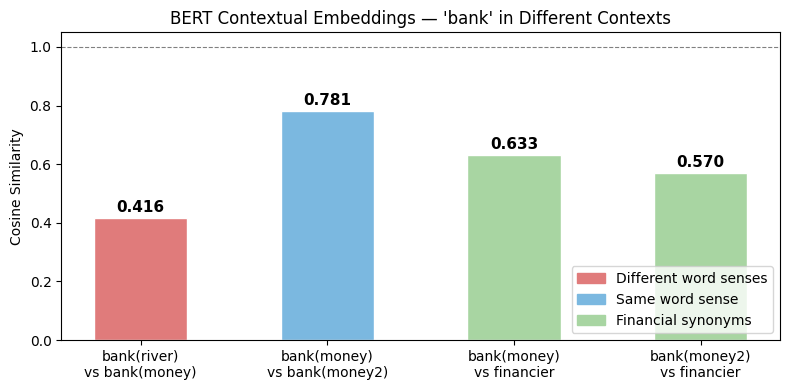

In [34]:
# Visualise the similarity scores as a bar chart
labels = ["bank(river)\nvs bank(money)",
          "bank(money)\nvs bank(money2)",
          "bank(money)\nvs financier",
          "bank(money2)\nvs financier"]
sims = [cosine_similarity(emb_river, emb_money),
        cosine_similarity(emb_money, emb_money2),
        cosine_similarity(emb_money, emb_financier),
        cosine_similarity(emb_money2, emb_financier)]
colors = ["#e07b7b", "#7bb8e0", "#a8d5a2", "#a8d5a2"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, sims, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cosine Similarity")
ax.set_title("BERT Contextual Embeddings — 'bank' in Different Contexts")
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", label="Perfect similarity")

for bar, val in zip(bars, sims):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#e07b7b", label="Different word senses"),
    mpatches.Patch(color="#7bb8e0", label="Same word sense"),
    mpatches.Patch(color="#a8d5a2", label="Financial synonyms"),
]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
plt.show()

**What the chart shows:**
- The same-sense pair scores highest — BERT produces nearly identical vectors when the word is used the same way.
- The different-sense pair scores lower — the same word token receives a meaningfully different representation depending on context.
- The synonym pair sits in between — "financier" and "bank" are semantically related in the financial domain, but they are different words with different surface forms.

**Note on subword splitting:** "financier" is not a single token in BERT's vocabulary — WordPiece splits it into `['fin', '##an', '##cier']`. The `get_token_embedding` function handles this automatically by averaging the three subword vectors into one 768-d representation. This is why `get_token_embedding` prints a note whenever it encounters a split word.

This is the core property that Word2Vec *cannot* reproduce — it would assign a single fixed vector to "bank" regardless of which sentence it appeared in.

---

## Part 3 — Masked Language Modelling

BERT was pre-trained with a **Masked Language Model (MLM)** objective: randomly replace tokens with `[MASK]` and train the model to predict the original token from the surrounding context.

We can run this directly — give BERT a sentence with a `[MASK]` and ask it what word belongs there. This is BERT doing what it was trained to do.

In [36]:
def fill_mask(sentence, top_k=5):
    """Predict the top-k most likely tokens for a [MASK] in a sentence."""
    inputs = tokenizer(sentence, return_tensors="pt")
    mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1].item()

    with torch.no_grad():
        logits = mlm_model(**inputs).logits  # shape: (1, seq_len, vocab_size)

    # Get the probability distribution over the vocabulary at the masked position
    probs = torch.softmax(logits[0, mask_idx], dim=-1)
    top_probs, top_ids = probs.topk(top_k)

    results = []
    for prob, token_id in zip(top_probs, top_ids):
        token = tokenizer.decode([token_id])
        results.append((token.strip(), prob.item()))
    return results


examples = [
    "The patient was taken to the [MASK] after the accident.",
    "She studied hard and passed her [MASK] with flying colours.",
    "The [MASK] signed a new treaty to end the conflict.",
    "I sat on the river [MASK] and watched the ducks.",
    "He withdrew money from the [MASK] machine.",
]

for sentence in examples:
    predictions = fill_mask(sentence, top_k=5)
    print(f"Sentence: {sentence}")
    for token, prob in predictions:
        bar = "█" * int(prob * 40)
        print(f"  {token:<15} {prob:.3f}  {bar}")
    print()

Sentence: The patient was taken to the [MASK] after the accident.
  hospital        0.986  ███████████████████████████████████████
  clinic          0.002  
  ambulance       0.002  
  hospitals       0.001  
  hospice         0.001  

Sentence: She studied hard and passed her [MASK] with flying colours.
  exams           0.393  ███████████████
  examinations    0.192  ███████
  exam            0.093  ███
  test            0.064  ██
  examination     0.061  ██

Sentence: The [MASK] signed a new treaty to end the conflict.
  parties         0.247  █████████
  two             0.062  ██
  nations         0.061  ██
  government      0.046  █
  british         0.035  █

Sentence: I sat on the river [MASK] and watched the ducks.
  ##bank          0.589  ███████████████████████
  bank            0.297  ███████████
  edge            0.015  
  banks           0.006  
  deck            0.006  

Sentence: He withdrew money from the [MASK] machine.
  answering       0.098  ███
  teller          0.

**Things to notice:**
- BERT uses *both* left and right context to make its prediction — it sees the full sentence, not just the words before the mask.
- The last two examples both contain the word that could be "bank" — the surrounding context steers the predictions differently.
- The probability distribution often has a clear winner, but sometimes several plausible words share probability mass.

Try modifying the sentences above with your own `[MASK]` placements to explore what BERT has learned.

---

## Part 4 — Sentence-Level Semantic Similarity

So far we have looked at individual token embeddings. For many practical tasks — search, clustering, duplicate detection — we need a single vector per sentence.

A common approach is **mean pooling**: average the final-layer hidden states across all tokens. This gives us a fixed-size 768-dimensional vector representing the whole sentence.

> **Note:** As discussed in the paper (section 5.4), mean pooling of a plain pre-trained BERT model does not produce optimal sentence embeddings for similarity tasks. Sentence-BERT (SBERT) fine-tunes this further. Here we use plain BERT to illustrate the concept — the pattern holds, but the absolute scores would be better with SBERT.

Let's compute sentence embeddings for a small set of sentences and visualise their pairwise similarities.

In [37]:
def get_sentence_embedding(sentence, model, tokenizer):
    """Mean-pool BERT's final hidden states to get a sentence embedding."""
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.last_hidden_state: (1, seq_len, 768)
    # Average across the sequence dimension (dim=1), excluding padding
    attention_mask = inputs["attention_mask"].unsqueeze(-1)  # (1, seq_len, 1)
    token_embeddings = outputs.last_hidden_state            # (1, seq_len, 768)
    sum_embeddings = (token_embeddings * attention_mask).sum(dim=1)
    count = attention_mask.sum(dim=1)
    mean_embedding = (sum_embeddings / count).squeeze(0).numpy()
    return mean_embedding


sentences = [
    "A dog is playing in the park.",          # animals / outdoors
    "A puppy is running on the grass.",        # animals / outdoors (similar)
    "The stock market fell sharply today.",    # finance
    "Investors are worried about inflation.",  # finance (similar)
    "She baked a chocolate cake for dessert.", # food / cooking
    "The recipe calls for two cups of flour.", # food / cooking (similar)
]

embeddings = [get_sentence_embedding(s, model, tokenizer) for s in sentences]

# Build pairwise cosine similarity matrix
n = len(sentences)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

print("Sentence embeddings computed.")
print(f"Each embedding: {embeddings[0].shape}")

Sentence embeddings computed.
Each embedding: (768,)


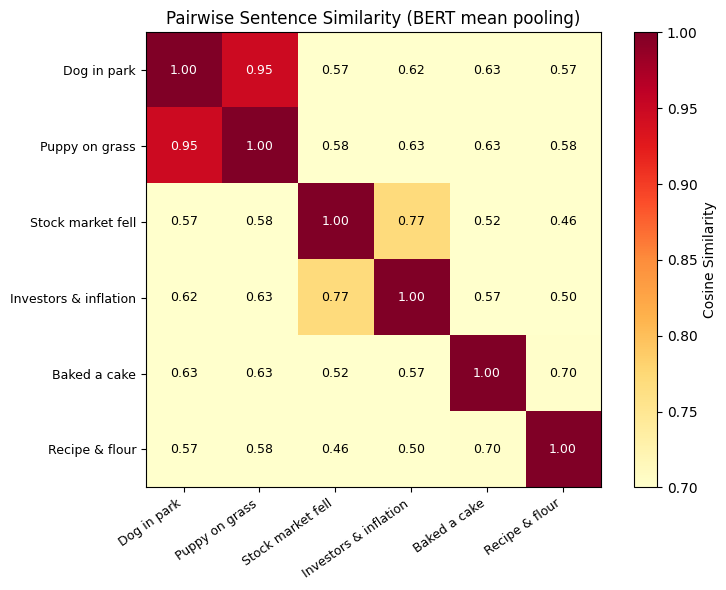

In [13]:
# Shorten labels for display
short_labels = [
    "Dog in park",
    "Puppy on grass",
    "Stock market fell",
    "Investors & inflation",
    "Baked a cake",
    "Recipe & flour",
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, vmin=0.7, vmax=1.0, cmap="YlOrRd")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

# Annotate each cell with the similarity value
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="black" if sim_matrix[i, j] < 0.92 else "white")

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Pairwise Sentence Similarity (BERT mean pooling)")
plt.tight_layout()
plt.show()

**What to look for in the heatmap:**
- The diagonal is always 1.0 (a sentence is identical to itself).
- Pairs within the same topic (animals, finance, food) should score higher than pairs across topics.
- The three topic clusters should be visible as brighter blocks along the diagonal.

Even with plain BERT mean pooling, the semantic groupings are recoverable — a fine-tuned sentence encoder (SBERT) would make these clusters much more pronounced.

---

## Summary

| Demonstration | What we learned |
|---|---|
| Tokenisation | BERT uses WordPiece subwords + `[CLS]` / `[SEP]` special tokens |
| Contextual embeddings | The same token gets a different 768-d vector depending on its sentence context |
| Masked Language Model | BERT uses both left and right context to predict masked tokens |
| Sentence similarity | Mean-pooled embeddings capture topical similarity even without fine-tuning |

These are the core capabilities that made BERT the dominant pre-training approach from 2018 onward, and the foundation for the LLMs and RAG systems we will explore in Sessions 7 and 8.